<a href="https://colab.research.google.com/github/mahsawye/robust-visual-segmentation/blob/main/notebooks/01_coco_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Imports


In [1]:
import json
import requests

from io import BytesIO
from PIL import Image

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 2. Download


In [ ]:
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip

# 3. Extract


In [ ]:
!unzip -q annotations_trainval2017.zip -d /content/

# 4. Configuration

In [4]:
annotation_path = "/content/annotations/instances_val2017.json"

# 4. Load COCO Dataset

In [5]:
with open(annotation_path, "r") as f:
    coco_data = json.load(f)

categories = coco_data["categories"]

In [6]:
# sanity check
print(coco_data.keys())
print("Number of images:", len(coco_data["images"]))
print("Number of annotations:", len(coco_data["annotations"]))
print("Number of categories:", len(coco_data["categories"]))

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])
Number of images: 5000
Number of annotations: 36781
Number of categories: 80


# 5. Helper Functions

In [7]:
# Convert a COCO bounding box from [x, y, width, height]
# to [x1, y1, x2, y2] format.
def coco_to_xyxy(coco_box):
    x, y, width, height = coco_box

    x1 = x
    y1 = y
    x2 = x + width
    y2 = y + height

    box_xyxy = [x1, y1, x2, y2]

    return [round(value, 2) for value in box_xyxy]

In [8]:
# sanity check
test_box = [473.07, 395.93, 38.65, 28.67]

print(coco_to_xyxy(test_box))

[473.07, 395.93, 511.72, 424.6]


In [9]:
# Find the category name corresponding to a COCO category ID.
def get_category_name(category_id, categories):
    for category in categories:
        if category["id"] == category_id:
            return category["name"]

In [10]:
# sanity check
print(get_category_name(18, categories))

dog


In [11]:
# Calculate Intersection over Union (IoU) between two bounding boxes.
# The boxes must be in [x1, y1, x2, y2] format.
def calculate_iou(box_a, box_b):
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])

    x_left = max(box_a[0], box_b[0])
    y_top = max(box_a[1], box_b[1])
    x_right = min(box_a[2], box_b[2])
    y_bottom = min(box_a[3], box_b[3])

    intersection_width = max(0, x_right - x_left)
    intersection_height = max(0, y_bottom - y_top)

    intersection_area = intersection_width * intersection_height

    union_area = area_a + area_b - intersection_area

    iou = intersection_area / union_area

    return iou

In [12]:
# sanity check
box_a = [0, 0, 10, 10]
box_b = [5, 5, 15, 15]

print(calculate_iou(box_a, box_b))

0.14285714285714285


# 6. Visualization

In [14]:
# Draw all bounding boxes and category labels on the image.
def draw_annotations(ax, image_annotations):
    for annotation in image_annotations:
        box_xyxy = coco_to_xyxy(annotation["bbox"])

        category_name = get_category_name(
            annotation["category_id"],
            categories
        )

        x1, y1, x2, y2 = box_xyxy

        rect = Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            y1,
            category_name,
            fontsize=10,
            verticalalignment="bottom"
        )

    ax.axis("off")

In [15]:
def visualize_image_annotations(image_id):
    # Find all annotations for the selected image.
    image_annotations = []

    for annotation in coco_data["annotations"]:
        if annotation["image_id"] == image_id:
            image_annotations.append(annotation)

    # Find the image information.
    image_info = None

    for image in coco_data["images"]:
        if image["id"] == image_id:
            image_info = image
            break

    # Load the image.
    file_name = image_info["file_name"]
    image_url = f"http://images.cocodataset.org/val2017/{file_name}"

    response = requests.get(image_url)
    image = Image.open(BytesIO(response.content))

    # Create the figure and display the image.
    fig, ax = plt.subplots(figsize=(6, 7))
    ax.imshow(image)

    # Draw all annotations.
    draw_annotations(ax, image_annotations)

    plt.show()

# 7. Sanity Checks

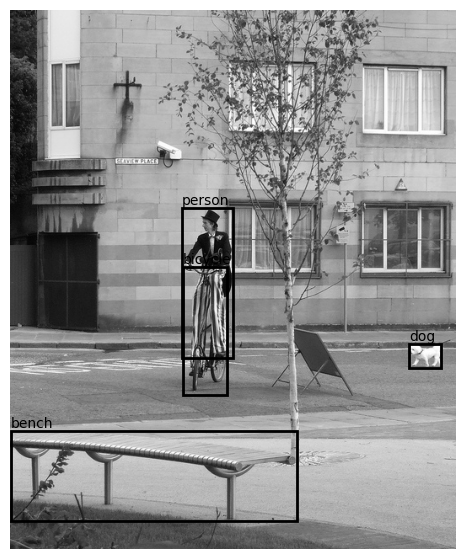

In [16]:
visualize_image_annotations(289343)

In [17]:
!git --version

git version 2.43.0


In [18]:
!git clone https://github.com/mahsawye/robust-visual-segmentation.git

Cloning into 'robust-visual-segmentation'...


In [19]:
%cd /content/robust-visual-segmentation

/content/robust-visual-segmentation


In [20]:
!git status

On branch main

No commits yet

nothing to commit (create/copy files and use "git add" to track)


In [21]:
!pwd

/content/robust-visual-segmentation
